In this assignment, you are given a dataset consisting of student information $X$ and their course grade $Y$ from `0` to `4`. You will implement and train a deep neural network to predict the grade you will get in this course, based on some information about yourself.

This assignment will focus mostly on implementation details. For example, how do we use optimizers in `torch`? How do we save and load model parameters? What does a training loop look like?

You will need to learn much of this information from the internet. The [PyTorch website](https://pytorch.org/tutorials/beginner/basics/intro.html) has many very good tutorials. An important part of deep learning is understanding how to read and use documentation! You are free to use any libraries or functions in this assignment.

You will need to do the following:
+ Create a train and test dataset (10 points)
+ Implement a deep neural network (20 points)
+ Implement a loss function (10 points)
+ Implement an optimizer and update equation (10 points)
+ Write a train loop and train the model (40 points)
+ Use the neural network to predict your personal course grade (10 points)

In [2]:
# Import libraries and download dataset
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import csv
import pandas as pd
import matplotlib.pyplot as plt

# First Download the dataset
! pip install -q kaggle
! kaggle datasets download -d waqi786/student-performance-dataset
! unzip -u student-performance-dataset.zip
! ls

Dataset URL: https://www.kaggle.com/datasets/waqi786/student-performance-dataset
License(s): apache-2.0
student-performance-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  student-performance-dataset.zip
BattleShip                      __pycache__
BattleShip 2                    asg1_mc451543.py
BattleShip.zip                  cisc_7026_2024_asg1_hw.ipynb
Battleship.ipynb                cisc_7026_2024_asg2_hw.ipynb
FashionMNIST                    cisc_7026_2024_asg3_hw.ipynb
Life_Expectancy_Data.csv        renderer testing.ipynb
Practice.ipynb                  student-performance-dataset.zip
Tutorial #1.ipynb               student_performance_data.csv
Tutorial #2.ipynb               test_data
Tutorial #3.ipynb               train_data


In [77]:
# Load the dataset
csv = pd.read_csv('student_performance_data.csv')
# Shuffle dataframe
csv = csv.sample(frac=1)
print(csv.keys()) # Print the meaning of the input dimensions
keys = ['StudyHoursPerWeek', 'AttendanceRate', 'ExtraCurricularActivities', 'PartTimeJob', 'Major']
csv['PartTimeJob'] = csv['PartTimeJob'] == 'Yes'
csv['ExtraCurricularActivities'] = csv['ExtraCurricularActivities'] == 'Yes'
print(csv['Major'].unique()) # Print all majors

# Neural networks are usually defined over real numbers
# Let us convert majors to real numbers
majors = {"Arts": 0.0, "Science": 1.0, "Education": 2.0, "Business": 3.0, "Engineering": 4.0}
csv['Major'] = csv['Major'].apply(lambda x: majors[x])

# Create dataset
xs = torch.stack([torch.from_numpy(csv[k].to_numpy()) for k in keys], axis=1).to(torch.float32) # Inputs
ys = torch.from_numpy(csv['GPA'].to_numpy()).to(torch.float32).reshape(-1, 1) # Outputs

Index(['StudentID', 'Gender', 'Age', 'StudyHoursPerWeek', 'AttendanceRate',
       'GPA', 'Major', 'PartTimeJob', 'ExtraCurricularActivities'],
      dtype='object')
['Engineering' 'Arts' 'Science' 'Education' 'Business']


(10 points)
Our dataset consists of `xs` and `ys`. First, compute `d_x, d_y` of the dataset. Then, you must create train datasets and test datasets.



In [78]:
d_h = 128
d_x = xs.shape[1]
d_y = ys.shape[1]

from sklearn.model_selection import train_test_split    
X_train, X_test, Y_train, Y_test = train_test_split(xs, ys, test_size=0.2, random_state=42)

(20 points)
Next, implement your neural network. You will need to implement the `__init__` method and the `forward` method. The following `torch` documentation might be helpful:

https://pytorch.org/docs/stable/generated/torch.nn.Module.html

https://pytorch.org/docs/stable/nn.html

In your `__init__` method, you should construct the parameters of the neural network. You might want to look at the second link for linear function.

In your `forward` method, you should push the input `x` through the layers of your neural network, and then return the output of the neural network. Remember that each layer consists of two parts!

After you create the neural network class, we will do a brief test to ensure it works. You will need to know the `d_x, d_y` of the dataset.

In [130]:
import torch.nn.functional as F

class NeuralNetwork(nn.Module):
  """Your neural network"""

  def __init__(self, d_x: int, d_h: int, d_y: int):
    super().__init__()
    self.d_x = d_x
    self.d_h = d_h
    self.d_y = d_y
    self.dataset_min = xs.min(axis=0).values
    self.dataset_max = xs.max(axis=0).values
    self.fc1 = nn.Linear(d_x, d_h)
    self.fc2 = nn.Linear(d_h, d_h // 2)
    self.fc3 = nn.Linear(d_h // 2, d_h // 4)
    self.fc4 = nn.Linear(d_h // 4, d_y)

  def forward(self, x):
    # Normalize inputs to be in [0, 1], this makes learning faster
    x = (x - self.dataset_min) / (self.dataset_max - self.dataset_min)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x)
    return x
# Finally, create our neural network to test that it works
net = NeuralNetwork(d_x, d_h, d_y)
# Predict for a single input
y_prediction = net(xs[0])
assert y_prediction.shape == (d_y,), "The neural network output should be of shape (d_y,)! Either d_y is wrong or your network is wrong."

(10 points)
Now, implement a loss function. You should compute the loss between the output of your neural network and the desired output `y`. You have done this in previous assignments. Instead of writing the square error on your own, use the `torch` implementation. Take a look at the documentation for the various loss functions. Make sure you select the correct loss function!

HINT: Sometimes, the square error loss is called the **m**ean **s**quare **e**rror.

https://pytorch.org/docs/stable/nn.functional.html#loss-functions


In [131]:
def loss_function(model: nn.Module, x: torch.Tensor, y: torch.Tensor):
    loss = nn.MSELoss()
    return loss(model(x), y)

(10 points) In the optimization lecture, we went over how to update parameters in `torch`. You will need to create an optimizer, then write a function that uses the optimizer to update the parameters. In `torch`, gradient descent is called `SGD`. The following documentation might be helpful:

https://pytorch.org/docs/stable/optim.html

https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html#optimizer

You might have to play with the learning rate. In the lectures, this is $\alpha$, but in `torch` this is called `lr`.


In [132]:
def make_optimizer(net: nn.Module) -> torch.optim.Optimizer:
    return torch.optim.SGD(net.parameters(), lr=0.001)

def update_parameters(model: nn.Module, x: torch.Tensor, y: torch.Tensor, optimizer: torch.optim.Optimizer) -> None:
  loss = loss_function(model, x, y)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  
# Test the optimizer and parameter update
net = NeuralNetwork(d_x, d_h, d_y)
opt = make_optimizer(net)
import copy
old_params = copy.deepcopy(list(net.parameters()))
update_parameters(torch.vmap(net), xs, ys, opt)
new_params = net.parameters()

for old, new in zip(old_params, new_params):
  assert torch.linalg.norm(old - new, ord=1) > 1e-5, "Your new parameters are the same as the old ones, are you sure you updated them?"
  assert old.grad is None, "You might be forgetting one last step..."

(20 points) Now, train your neural network. One `epoch` means one training update over the dataset. You will need to do a few things in the for loop:

1. You will need to backpropagate the loss and update the parameters
2. You will need to record the loss on the training dataset
3. You will need to record the loss on the testing dataset
4. You will need to plot the training and testing losses over time
  HINT: You might need to call `.detach()` on your loss values before plotting them. Otherwise, you might get an error. This is a safety mechanism because `torch` wants to protect the gradient.

Fortunately, you have just written the `update_parameters` method to accomplish point 1, and implemented `loss_function` for points 2 and 3!

(10 points) After you train your network and see the losses decrease, you will need to follow some more steps
1. You will need to store the training and testing losses for each epoch
2. You will need to save the parameters with the smallest test loss using `net.state_dict()`
  HINT: You should keep track of the test loss and update the parameters when the test loss is lower than the lowest test loss



Epoch 0/1000 Train_LOSS 8.139291763305664 Test LOSS 8.626910209655762
Epoch 1/1000 Train_LOSS 8.078770637512207 Test LOSS 8.564152717590332
Epoch 2/1000 Train_LOSS 8.018712043762207 Test LOSS 8.50184440612793
Epoch 3/1000 Train_LOSS 7.959102630615234 Test LOSS 8.439926147460938
Epoch 4/1000 Train_LOSS 7.899965286254883 Test LOSS 8.378451347351074
Epoch 5/1000 Train_LOSS 7.841320037841797 Test LOSS 8.317395210266113
Epoch 6/1000 Train_LOSS 7.783054828643799 Test LOSS 8.256712913513184
Epoch 7/1000 Train_LOSS 7.72517204284668 Test LOSS 8.196386337280273
Epoch 8/1000 Train_LOSS 7.667614936828613 Test LOSS 8.136430740356445
Epoch 9/1000 Train_LOSS 7.610321521759033 Test LOSS 8.076801300048828
Epoch 10/1000 Train_LOSS 7.553326606750488 Test LOSS 8.017511367797852
Epoch 11/1000 Train_LOSS 7.496635913848877 Test LOSS 7.958615779876709
Epoch 12/1000 Train_LOSS 7.440229415893555 Test LOSS 7.8999834060668945
Epoch 13/1000 Train_LOSS 7.384077548980713 Test LOSS 7.841611385345459
Epoch 14/1000 Tra

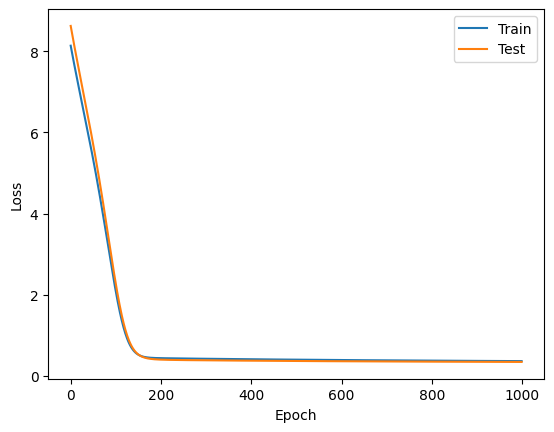

In [133]:
# Create a new optimizer and neural network each time
# that way if we mess them up, the are reset when we rerun this cell
net = NeuralNetwork(d_x, d_h, d_y)
opt = make_optimizer(net)

num_train_epochs = 1000 # How many times we update parameters

best_params = None
testing_losses = torch.ones(num_train_epochs)
training_losses = torch.ones(num_train_epochs)

best_loss = torch.inf
for epoch in range(num_train_epochs):
    update_parameters(net, X_train, Y_train, opt)
    train_loss = loss_function(net, X_train, Y_train)
    training_losses[epoch] = train_loss.detach()
    
    with torch.no_grad():
        test_loss = loss_function(net, X_test, Y_test)
        testing_losses[epoch] = test_loss.detach()
        if test_loss < best_loss:
            best_params = net.state_dict()
        
    print("Epoch {}/{} Train_LOSS {} Test LOSS {}".format(epoch, num_train_epochs, train_loss, test_loss))

            
# raise NotImplementedError("TODO: Implement your training loop")
# best_params = None # TODO
# training_losses = torch.ones(num_train_epochs) # TODO
# testing_losses = torch.ones(num_train_epochs) # TODO
plt.plot(range(num_train_epochs), training_losses)
plt.plot(range(num_train_epochs), testing_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.show()

(10 points) Finally, predict your course grade (0.0 to 4.0) by putting your personal information into the model with the lowest test loss!

All you need to do is fill out the correct information in `my_info`. Play around and see what attributes make a good student.

In [134]:
# Load the best performing parameters into the neural network
net = NeuralNetwork(d_x, d_h, d_y)
net.load_state_dict(best_params)

# No need to lie, I do not care how much you study or attend class
my_info = torch.tensor([
    40.0, # Study hours per week
    100.0, # Attendance rate between 0 and 100 -- 100 means you attended every class
    1.0, # Extracurricular activities, 1 for yes and 0 for no
    1.0, # Part-time job, 1 for yes and 0 for no
    majors["Science"] # Can be Arts, Science, Education, Business, or Engineering
])

my_predicted_grade = net(my_info)
print(f"My estimated grade: {my_predicted_grade.item():.2f} / 4.0")

My estimated grade: 3.40 / 4.0
